<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/3P/ProyectoP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Proyecto: Reconocimiento de Voz "Luz Inteligente"
**Minería de Datos**
**Fecha de entrega:** 25 de mayo de 2026

### 👥 Integrantes:
* Nombre Apellido 1
* Nombre Apellido 2...

---
## 📑 Índice
1. [Introducción Teórica](#intro)
2. [Importación de Librerías](#libs)
3. [Carga y Procesamiento de Datos](#datos)
4. [Construcción del Modelo](#modelo)
5. [Resultados y Gráficas](#resultados)

In [11]:
# Paso 1.2: Importación de herramientas

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from google.colab import drive

# Montar Drive para acceder a los audios
drive.mount('/content/drive')

"""
Fase 2: Adquisición y Procesamiento de Datos
Paso 2.1: Estructura en Drive

Organiza tus carpetas así:
/MiDrive/ProyectoAudio/encender/ (61 audios)
/MiDrive/ProyectoAudio/apagar/ (61 audios)
"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


' \nFase 2: Adquisición y Procesamiento de Datos\nPaso 2.1: Estructura en Drive\n\nOrganiza tus carpetas así:\n/MiDrive/ProyectoAudio/encender/ (61 audios)\n/MiDrive/ProyectoAudio/apagar/ (61 audios)\n'

In [12]:
# Paso 2.2 y 2.3: Función de Extracción y Padding

def extract_features(file_path, max_pad_len=40):
    try:
        # Cargar audio
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        # Extraer MFCC (usualmente 40 coeficientes)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

        # Padding o Truncamiento para que todos midan lo mismo
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs
    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

# Aquí iterarías sobre tus carpetas de Drive para llenar 'X' (datos) y 'y' (etiquetas 0 y 1)

In [13]:
# Fase 3: Desarrollo del Modelo y Optimización
# Paso 3.1 y 3.2: Arquitectura y Tuning


def build_model(num_layers=2, neurons=64):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(40, 40))) # 40 MFCCs x 40 de tiempo

    # Capas Ocultas Dinámicas para tu experimento
    for _ in range(num_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.Dropout(0.2)) # Ayuda a no sobreentrenar

    model.add(layers.Dense(1, activation='sigmoid')) # Salida Binaria

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model



# Ejemplo de entrenamiento
model = build_model(num_layers=2, neurons=128)
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5625 - loss: 0.8726 - val_accuracy: 0.5500 - val_loss: 0.6703
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6000 - loss: 0.7457 - val_accuracy: 0.5500 - val_loss: 0.7367
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5500 - loss: 0.7213 - val_accuracy: 0.5500 - val_loss: 0.6714
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 - loss: 0.7362 - val_accuracy: 0.6000 - val_loss: 0.6813
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.6520 - val_accuracy: 0.5500 - val_loss: 0.7293
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 - loss: 0.6351 - val_accuracy: 0.4000 - val_loss: 0.6974
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7375 - loss: 0.5126 - val_accuracy: 0.5500 - val_loss: 0.7741
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7000 - loss: 0.5684 - val_accuracy: 0.6500 - v

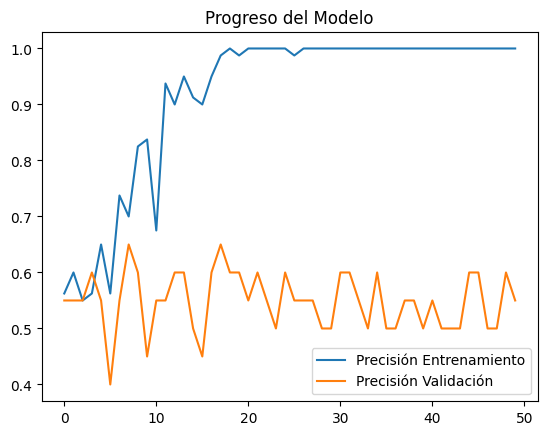

In [16]:
# Paso 3.3: Graficar resultados

plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Progreso del Modelo')
plt.legend()
plt.show()

In [17]:
# Fase 4: Evaluación y Resultados
# Paso 4.1: Simulación

def predecir_comando(file_path):
    features = extract_features(file_path)
    features = features.reshape(1, 40, 40)
    prediccion = model.predict(features)

    if prediccion > 0.5:
        print(f"Resultado: LUZ ENCENDIDA ({prediccion[0][0]:.2f})")
    else:
        print(f"Resultado: LUZ APAGADA ({prediccion[0][0]:.2f})")